<a href="https://colab.research.google.com/github/Wdwood12/Data620_Web_Analytic/blob/main/HSP_Workforce_final_data620.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [269]:
#=============================
# 1. Import Libraries
#=============================

import kagglehub
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter
import re



In [270]:
#=============================
# 2. Load Dataset
#=============================

path = kagglehub.dataset_download("vanpatangan/hospital-supply-chain")
files = os.listdir(path)
print("Files:", files)

# Load the main CSV file
file_path = os.path.join(path, files[0])
df = pd.read_csv(file_path)

# Show first few rows
df.head(10)

Using Colab cache for faster access to the 'hospital-supply-chain' dataset.
Files: ['staff_data.csv', 'vendor_data.csv', 'financial_data.csv', 'inventory_data.csv', 'patient_data.csv']


,Staff_ID,Staff_Type,Shift_Date,Shift_Start_Time,Shift_End_Time,Current_Assignment,Hours_Worked,Patients_Assigned,Overtime_Hours
0,S001,Surgeon,2024-10-22 04:44:49,06:00 PM,07:00 PM,ER,8,9,1
1,S002,Nurse,2024-10-03 05:51:36,08:00 AM,06:00 PM,General Ward,9,3,0
2,S003,Technician,2024-10-15 15:11:14,08:00 AM,06:00 PM,ER,8,6,4
3,S004,Surgeon,2024-10-09 20:07:58,07:00 AM,06:00 PM,General Ward,11,6,3
4,S005,Surgeon,2024-10-12 05:01:02,07:00 AM,06:00 AM,General Ward,9,5,3
5,S006,Surgeon,2024-10-05 12:17:25,06:00 PM,07:00 PM,General Ward,10,5,2
6,S007,Nurse,2024-10-18 20:26:07,07:00 AM,06:00 PM,ER,11,8,1
7,S008,Nurse,2024-10-08 21:16:16,07:00 AM,07:00 PM,ICU Surgery,8,7,0
8,S009,Technician,2024-10-22 04:53:34,08:00 AM,06:00 PM,General Ward,11,6,2
9,S010,Surgeon,2024-10-03 02:48:39,08:00 AM,07:00 PM,ICU Surgery,9,5,3


In [271]:
#=============================
# 3. Data Validation
#=============================

print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nUnique Staff Types:")
print(df['Staff_Type'].unique())

print("\nUnique Departments:")
print(df['Current_Assignment'].unique())

Dataset Shape: (500, 9)

Missing Values:
Staff_ID              0
Staff_Type            0
Shift_Date            0
Shift_Start_Time      0
Shift_End_Time        0
Current_Assignment    0
Hours_Worked          0
Patients_Assigned     0
Overtime_Hours        0
dtype: int64

Unique Staff Types:
['Surgeon' 'Nurse' 'Technician']

Unique Departments:
['ER' 'General Ward' 'ICU Surgery']


In [272]:
# Convert shift date to datetime
df['Shift_Date'] = pd.to_datetime(df['Shift_Date'])

# Create weekday column
df['Weekday'] = df['Shift_Date'].dt.day_name()

# Extract hour for operational trends
df['Shift_Hour'] = df['Shift_Date'].dt.hour

df.head()

,Staff_ID,Staff_Type,Shift_Date,Shift_Start_Time,Shift_End_Time,Current_Assignment,Hours_Worked,Patients_Assigned,Overtime_Hours,Weekday,Shift_Hour
0,S001,Surgeon,2024-10-22 04:44:49,06:00 PM,07:00 PM,ER,8,9,1,Tuesday,4
1,S002,Nurse,2024-10-03 05:51:36,08:00 AM,06:00 PM,General Ward,9,3,0,Thursday,5
2,S003,Technician,2024-10-15 15:11:14,08:00 AM,06:00 PM,ER,8,6,4,Tuesday,15
3,S004,Surgeon,2024-10-09 20:07:58,07:00 AM,06:00 PM,General Ward,11,6,3,Wednesday,20
4,S005,Surgeon,2024-10-12 05:01:02,07:00 AM,06:00 AM,General Ward,9,5,3,Saturday,5


In [273]:
# ============================================
# 4. Feature Engineering
# ============================================
df['Operational_Pressure_Index'] = (
    df['Patients_Assigned'] /
    df['Hours_Worked']
)

In [274]:
# ============================================
# 5. Workforce Disruption Modeling
# ============================================

no_show_rate = 0.10      # 10% staff unavailable
lateness_rate = 0.20     # 20% productivity reduction

print("No-Show Rate:", no_show_rate)
print("Lateness Rate:", lateness_rate)

No-Show Rate: 0.1
Lateness Rate: 0.2


In [275]:
# ============================================
# 6. Exploratory Data Analysis
# ============================================
def apply_disruption(df, no_show_rate, lateness_rate):

    disrupted = df.copy()

    # Simulate no-shows
    disrupted['Adjusted_Hours'] = (
        disrupted['Hours_Worked'] * (1 - no_show_rate)
    )

    # Simulate lateness reduction
    disrupted['Adjusted_Hours'] = (
        disrupted['Adjusted_Hours'] * (1 - lateness_rate)
    )

    # Avoid divide-by-zero
    disrupted['Adjusted_Hours'] = disrupted['Adjusted_Hours'].clip(lower=1)

    # Recalculate indexes
    disrupted['Adjusted_Supply_Risk'] = (
        disrupted['Patients_Assigned'] /
        disrupted['Adjusted_Hours']
    )

    disrupted['Adjusted_Wait_Time'] = (
        disrupted['Patients_Assigned'] /
        disrupted['Adjusted_Hours']
    )

    return disrupted

In [276]:
# ============================================
# 7. Network Analysis
# ============================================
scenarios = {
    "Efficient": (0.0, 0.0),
    "Moderate Stress": (0.1, 0.2),
    "Inefficient": (0.2, 0.3)
}

scenario_results = {}

for name, (no_show, late) in scenarios.items():

    result = apply_disruption(df, no_show, late)

    scenario_results[name] = {
        "Avg Supply Risk":
            result['Adjusted_Supply_Risk'].mean(),

        "Avg Wait Time":
            result['Adjusted_Wait_Time'].mean(),

        "Avg Overtime":
            result['Overtime_Hours'].mean()
    }

scenario_df = pd.DataFrame(scenario_results).T

print(scenario_df)

                 Avg Supply Risk  Avg Wait Time  Avg Overtime
Efficient               0.532360       0.532360         1.962
Moderate Stress         0.739389       0.739389         1.962
Inefficient             0.950643       0.950643         1.962


In [277]:
# ============================================
# 8. Text Processing
# ============================================
df['Adjusted_Capacity'] = (
    df['Hours_Worked']
    * (1 - no_show_rate)
    * (1 - lateness_rate)
)

df[['Hours_Worked', 'Adjusted_Capacity']].head()

,Hours_Worked,Adjusted_Capacity
0,8,5.76
1,9,6.48
2,8,5.76
3,11,7.92
4,9,6.48


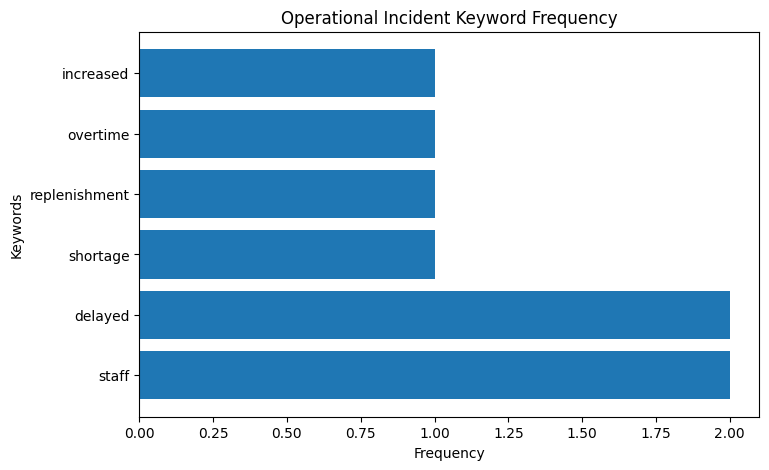

In [297]:
# Keyword Frequency Chart

keywords = dict(word_counts.most_common(6))

plt.figure(figsize=(8,5))

plt.barh(
    list(keywords.keys()),
    list(keywords.values())
)

plt.title("Operational Incident Keyword Frequency")

plt.xlabel("Frequency")

plt.ylabel("Keywords")

plt.show()

In [278]:

if 'Supply_Risk_Index' not in df.columns:
    df['Supply_Risk_Index'] = df['Operational_Pressure_Index']
if 'Wait_Time_Index' not in df.columns:
    df['Wait_Time_Index'] = df['Operational_Pressure_Index']

# Apply the disruption scenario using the global no_show_rate and lateness_rate
disrupted_df = apply_disruption(df, no_show_rate, lateness_rate)

comparison = pd.DataFrame({

    'Baseline_Risk':
        df['Supply_Risk_Index'],

    'Disrupted_Risk':
        disrupted_df['Adjusted_Supply_Risk'],

    'Baseline_Wait':
        df['Wait_Time_Index'],

    'Disrupted_Wait':
        disrupted_df['Adjusted_Wait_Time']
})

comparison.describe()

,Baseline_Risk,Disrupted_Risk,Baseline_Wait,Disrupted_Wait
count,500.000000,500.000000,500.000000,500.000000
mean,0.532360,0.739389,0.532360,0.739389
std,0.283138,0.393247,0.283138,0.393247
min,0.090909,0.126263,0.090909,0.126263
25%,0.272727,0.378788,0.272727,0.378788
50%,0.500000,0.694444,0.500000,0.694444
75%,0.750000,1.041667,0.750000,1.041667
max,1.125000,1.562500,1.125000,1.562500


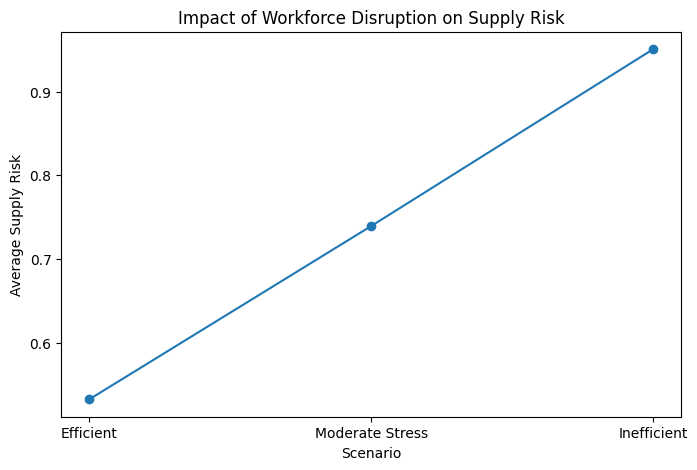

In [279]:
scenario_labels = ['Efficient', 'Moderate Stress', 'Inefficient']

avg_risk = []

for no_show, late in scenarios.values():

    adjusted_capacity = (
        df['Hours_Worked']
        * (1 - no_show)
        * (1 - late)
    )

    risk = (
        df['Patients_Assigned'] /
        adjusted_capacity
    ).mean()

    avg_risk.append(risk)

plt.figure(figsize=(8,5))

plt.plot(
    scenario_labels,
    avg_risk,
    marker='o'
)

plt.title("Impact of Workforce Disruption on Supply Risk")

plt.xlabel("Scenario")

plt.ylabel("Average Supply Risk")

plt.show()

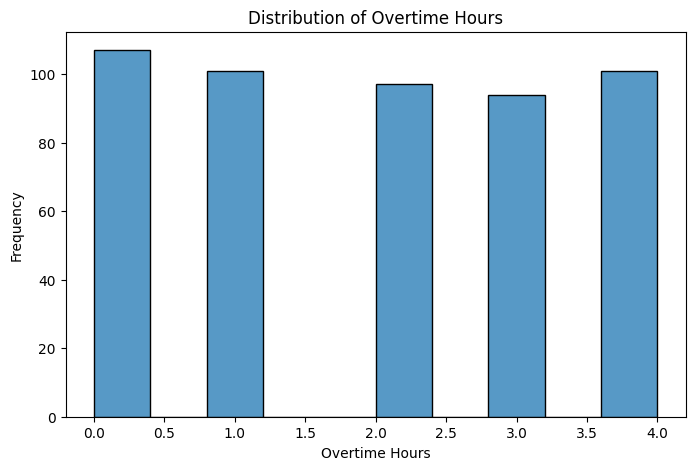

In [280]:


plt.figure(figsize=(8,5))

sns.histplot(df['Overtime_Hours'], bins=10)

plt.title("Distribution of Overtime Hours")
plt.xlabel("Overtime Hours")
plt.ylabel("Frequency")

plt.show()

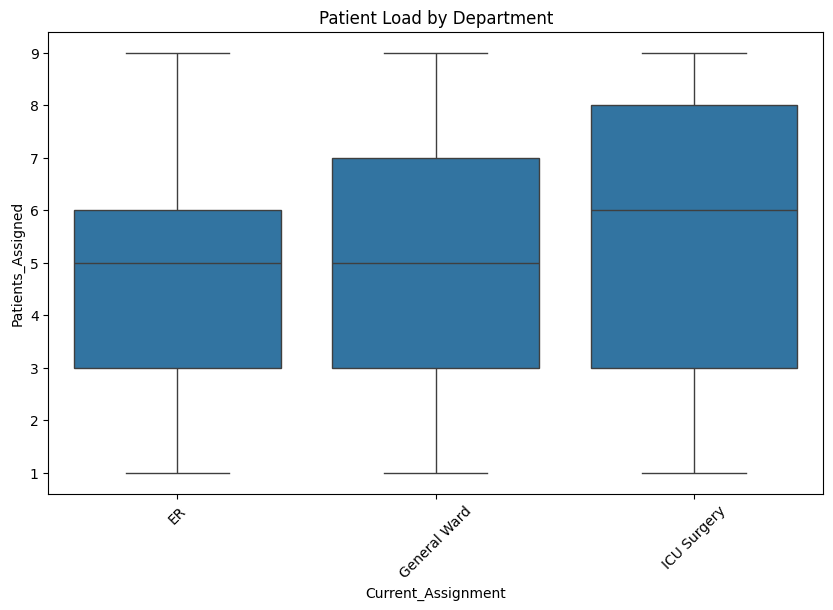

In [281]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Current_Assignment',
    y='Patients_Assigned'
)

plt.xticks(rotation=45)

plt.title("Patient Load by Department")

plt.show()

In [282]:


B = nx.Graph()

# Add staff nodes
staff_nodes = df['Staff_ID'].unique()

B.add_nodes_from(staff_nodes, bipartite=0)

# Add department nodes
dept_nodes = df['Current_Assignment'].unique()

B.add_nodes_from(dept_nodes, bipartite=1)

# Add edges
edges = list(
    zip(df['Staff_ID'], df['Current_Assignment'])
)

B.add_edges_from(edges)

print("Nodes:", B.number_of_nodes())
print("Edges:", B.number_of_edges())

Nodes: 503
Edges: 500


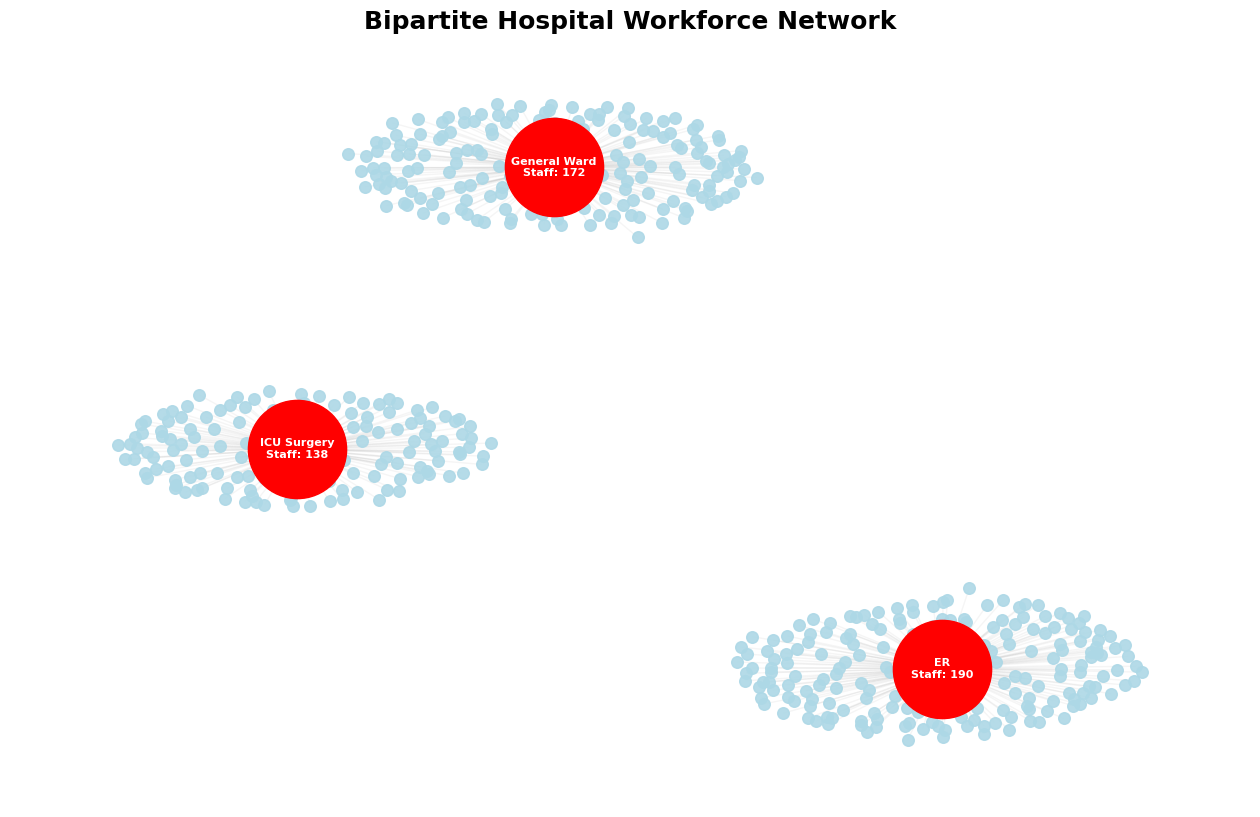

In [283]:
# Bipartite Hospital Workforce Network

plt.figure(figsize=(16,10))

# Spring layout
pos = nx.spring_layout(
    B,
    seed=42,
    k=0.55
)

# Draw edges
nx.draw_networkx_edges(
    B,
    pos,
    alpha=0.08,
    edge_color='gray'
)

# Draw staff nodes
nx.draw_networkx_nodes(
    B,
    pos,
    nodelist=staff_nodes,
    node_color='lightblue',
    node_size=70,
    alpha=0.9
)

# Draw department nodes
nx.draw_networkx_nodes(
    B,
    pos,
    nodelist=dept_nodes,
    node_color='red',
    node_size=5000
)

# Department labels with counts
dept_labels = {
    dept:
    f"{dept}\nStaff: {df[df['Current_Assignment']==dept].shape[0]}"
    for dept in dept_nodes
}

nx.draw_networkx_labels(
    B,
    pos,
    labels=dept_labels,
    font_size=8,
    font_weight='bold',
    font_color='white'
)

# Title
plt.title(
    "Bipartite Hospital Workforce Network",
    fontsize=18,
    fontweight='bold'
)

plt.axis('off')

plt.show()

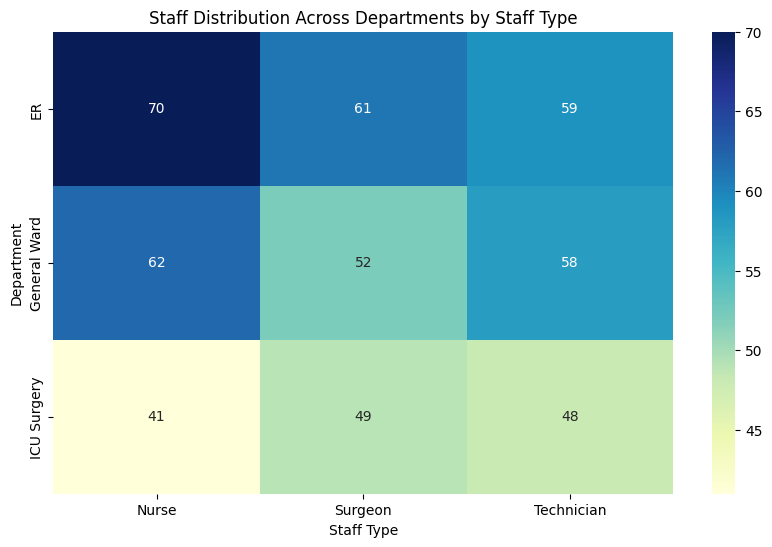

In [284]:
# Count Staff_Type individually in each Current_Assignment
staff_dept_counts = df.groupby(['Current_Assignment', 'Staff_Type']).size().unstack(fill_value=0)

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(staff_dept_counts, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Staff Distribution Across Departments by Staff Type")
plt.xlabel("Staff Type")
plt.ylabel("Department")
plt.show()

In [285]:
# Staff count per department
dept_staff_counts = df['Current_Assignment'].value_counts()

# Top 5 departments by staff count
print("Top 5 Departments by Staff Count:")
print(dept_staff_counts.head(5))

Top 5 Departments by Staff Count:
Current_Assignment
ER              190
General Ward    172
ICU Surgery     138
Name: count, dtype: int64


In [286]:
centrality = nx.degree_centrality(B)

centrality_df = pd.DataFrame({
    'Node': centrality.keys(),
    'Centrality': centrality.values()
})

centrality_df.sort_values(
    by='Centrality',
    ascending=False
).head(10)

,Node,Centrality
500,ER,0.378486
501,General Ward,0.342629
502,ICU Surgery,0.274900
330,S331,0.001992
331,S332,0.001992
332,S333,0.001992
333,S334,0.001992
334,S335,0.001992
335,S336,0.001992
337,S338,0.001992


In [287]:
incident_notes = [
    "Staff shortage delayed replenishment",
    "Overtime increased due to no-show",
    "Patient wait time exceeded target",
    "Supply delivery delayed during peak hours",
    "Critical department overloaded",
    "Late staff arrival caused workflow delay"
]

In [288]:

all_words = []

for note in incident_notes:

    words = re.findall(r'\w+', note.lower())

    all_words.extend(words)

word_counts = Counter(all_words)

print(word_counts.most_common(10))

[('staff', 2), ('delayed', 2), ('shortage', 1), ('replenishment', 1), ('overtime', 1), ('increased', 1), ('due', 1), ('to', 1), ('no', 1), ('show', 1)]


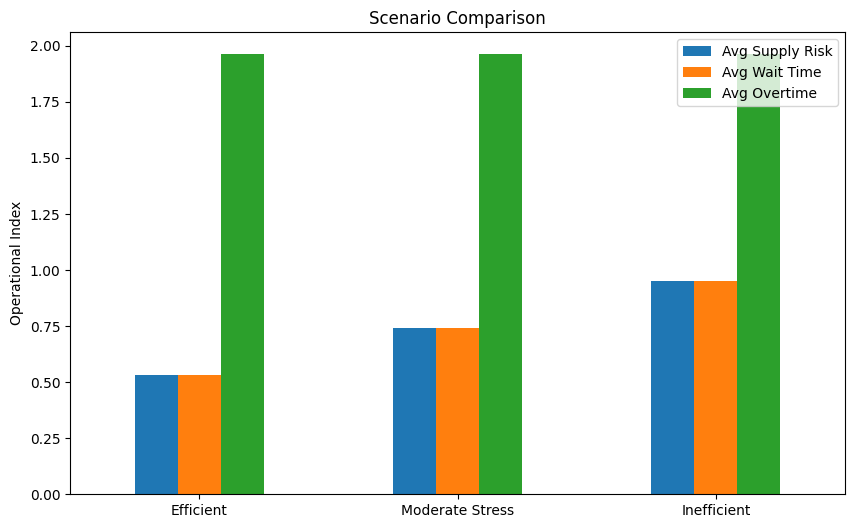

In [289]:
scenario_df.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Scenario Comparison")

plt.ylabel("Operational Index")

plt.xticks(rotation=0)

plt.show()

In [290]:
efficiency_results = []

scenarios = {
    "Efficient": (0.0, 0.0),
    "Moderate Stress": (0.1, 0.2),
    "Inefficient": (0.2, 0.3)
}

for label, (no_show, late) in zip(scenario_labels, scenarios.values()):

    adjusted_capacity = (
        df['Hours_Worked']
        * (1 - no_show)
        * (1 - late)
    )

    supply_risk = (
        df['Patients_Assigned'] /
        adjusted_capacity
    ).mean()

    wait_time = (
        df['Patients_Assigned'] /
        adjusted_capacity
    ).mean()

    overtime = df['Overtime_Hours'].mean()

    efficiency_results.append({
        "Scenario": label,
        "No_Show_Rate": no_show,
        "Lateness_Rate": late,
        "Avg_Supply_Risk": round(supply_risk, 2),
        "Avg_Wait_Time": round(wait_time, 2),
        "Avg_Overtime": round(overtime, 2)
    })

efficiency_df = pd.DataFrame(efficiency_results)

print(efficiency_df)

          Scenario  No_Show_Rate  Lateness_Rate  Avg_Supply_Risk  \
0        Efficient           0.0            0.0             0.53   
1  Moderate Stress           0.1            0.2             0.74   
2      Inefficient           0.2            0.3             0.95   

   Avg_Wait_Time  Avg_Overtime  
0           0.53          1.96  
1           0.74          1.96  
2           0.95          1.96  


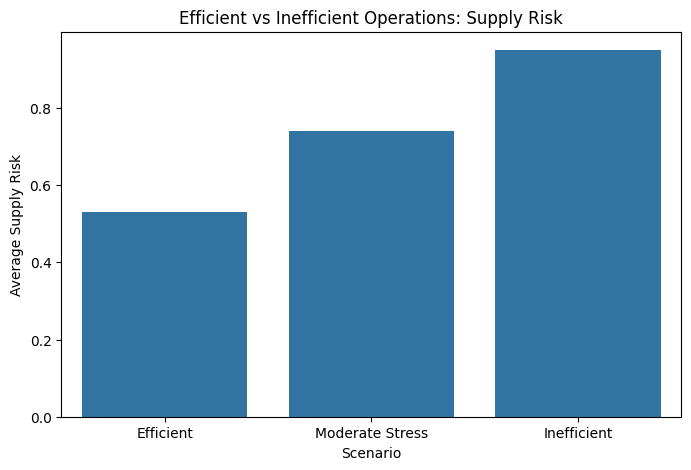

In [291]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=efficiency_df,
    x='Scenario',
    y='Avg_Supply_Risk'
)

plt.title("Efficient vs Inefficient Operations: Supply Risk")

plt.ylabel("Average Supply Risk")

plt.show()

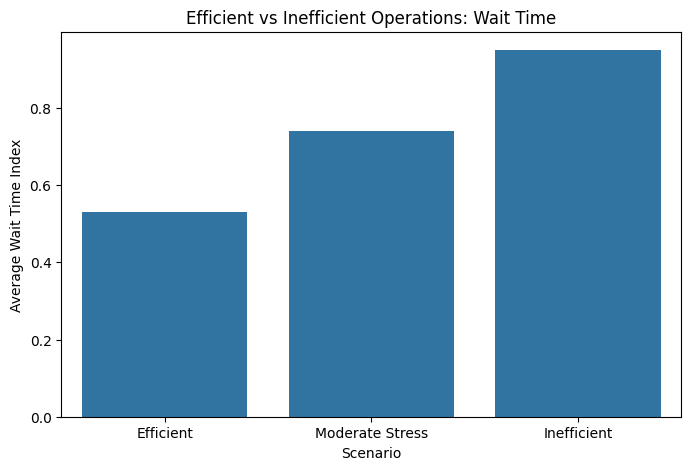

In [292]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=efficiency_df,
    x='Scenario',
    y='Avg_Wait_Time'
)

plt.title("Efficient vs Inefficient Operations: Wait Time")

plt.ylabel("Average Wait Time Index")

plt.show()

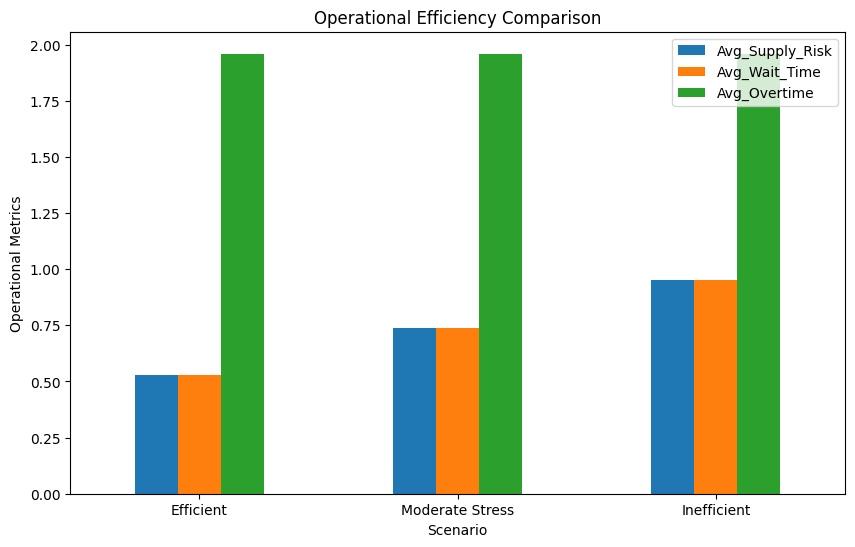

In [293]:
efficiency_df.set_index('Scenario')[[
    'Avg_Supply_Risk',
    'Avg_Wait_Time',
    'Avg_Overtime'
]].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Operational Efficiency Comparison")

plt.ylabel("Operational Metrics")

plt.xticks(rotation=0)

plt.show()

In [294]:

# ============================================
# 9. Operational Stability Index
# ============================================
df['Overtime_Factor'] = (
    df['Overtime_Hours'] /
    df['Overtime_Hours'].max()
)

# Build OSI Baseline
# Define Supply_Risk_Index and Wait_Time_Index
# Assuming these are based on the Operational_Pressure_Index for baseline
if 'Supply_Risk_Index' not in df.columns:
    df['Supply_Risk_Index'] = df['Operational_Pressure_Index']
if 'Wait_Time_Index' not in df.columns:
    df['Wait_Time_Index'] = df['Operational_Pressure_Index']

df['Operational_Stability_Index'] = 1 / (
    1
    + df['Supply_Risk_Index']
    + df['Wait_Time_Index']
    + df['Overtime_Factor']
)

df[['Operational_Stability_Index']].head()
osi_results = []

# Build Scenario OSI Comparison

scenarios = {
    "Efficient": (0.0, 0.0),
    "Moderate Stress": (0.1, 0.2),
    "Inefficient": (0.2, 0.3)
}

osi_results = []

for label, (no_show, late) in scenarios.items():

    adjusted_capacity = (
        df['Hours_Worked']
        * (1 - no_show)
        * (1 - late)
    )

    operational_pressure = (
        df['Patients_Assigned'] /
        adjusted_capacity
    )

    overtime_factor = (
        df['Overtime_Hours'].mean()
        * (1 + no_show + late)
    ) / df['Overtime_Hours'].max()

    osi = 1 / (
        1
        + operational_pressure
        + overtime_factor
    )

    osi_results.append({
        "Scenario": label,
        "Average_OSI": osi.mean()
    })

osi_df = pd.DataFrame(osi_results)

print(osi_df)

          Scenario  Average_OSI
0        Efficient     0.504153
1  Moderate Stress     0.432476
2      Inefficient     0.385909


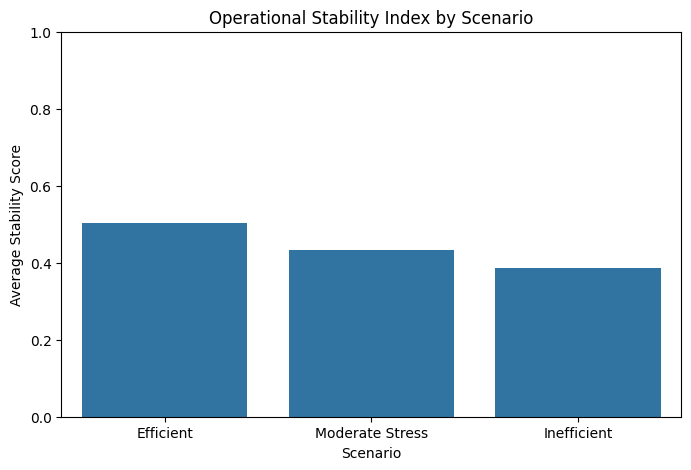

In [295]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=osi_df,
    x='Scenario',
    y='Average_OSI'
)

plt.title("Operational Stability Index by Scenario")

plt.ylabel("Average Stability Score")

plt.ylim(0, 1)

plt.show()

In [296]:
# ============================================
# 10. Key Findings and Conclusion
# ============================================

# Key Findings
# - Workforce interruptions led to increasing operational strain.
# - Supply risk increased dramatically under inefficient conditions.
# - Patient wait times increased with staffing disruption.
# - The operational Stability Index (OSI) dropped as no-show and lateness rates increased.
# - The emergency room has the highest worker reliance.

# Operational Implications
# The findings indicates that workforce instability may create flowing impacts
# Across patient throughput, staffing efficiency, overtime reliance,and supply chain responsiveness.